# 3. Machine Learning for Classification

## 3.1 Churn Prediction
 

[Kaggle Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 3.2 Data Preparation


In [121]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [122]:
data_url = 'https://github.com/alexeygrigorev/mlbookcamp-code/raw/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [123]:
df = pd.read_csv('data-week-3.csv')

In [124]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [125]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


### Standardize the data
for categorical data:
- replace spaces with `_`
- transform to lower case

!NOTE! Same as week 2

In [126]:
df.columns = df.columns.str.lower().str.replace(' ', "_")

In [127]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [128]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [129]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')


In [130]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [131]:
df['totalcharges'] = pd.to_numeric(df.totalcharges, errors='coerce').fillna(0)

In [132]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [133]:
df['churn'] = (df.churn == 'yes').astype(int)

In [134]:
df.churn.unique()

array([0, 1])

## 3.3 Setting up the Validation Framework

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
# First split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [137]:
len(df), len(df_full_train), len(df_test)

(7043, 5634, 1409)

In [138]:
# Second Split
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [139]:
len(df), len(df_train), len(df_val), len(df_test)

(7043, 4225, 1409, 1409)

In [140]:
# reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [141]:
# get y
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [142]:
# delete churn
del df_train['churn']
del df_val['churn']
del df_test['churn']

## 3.4 EDA

In [143]:
df_full_train.reset_index()


,index,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,905,0781-lkxbr,male,1,no,no,9,yes,yes,fiber_optic,...,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.60,1
5630,5192,3507-gasnp,male,0,no,yes,60,yes,no,no,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.90,0
5631,3980,8868-wozgu,male,0,no,no,28,yes,yes,fiber_optic,...,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.50,1
5632,235,1251-krreg,male,0,no,no,2,yes,yes,dsl,...,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.10,1


In [144]:
df_full_train.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [145]:
df_full_train.churn.value_counts(normalize=True)

0    0.730032
1    0.269968
Name: churn, dtype: float64

In [146]:
df_full_train.churn.mean()

0.26996805111821087

In [147]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

0.27

### Numerical Variables

In [148]:
df_full_train.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int32
dtype: object

In [149]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [150]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']


In [151]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [152]:
# get the number of unique values
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.5 Feature Importance: Churn Rate aad Risk Ratio 

### Churn rate within each group

In [153]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [154]:
# churn rate for gender: female
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

0.27682403433476394

In [155]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

0.2632135306553911

In [156]:
global_churn = df_full_train.churn.mean()
global_churn

0.26996805111821087

In [157]:
df_full_train.partner.value_counts()

no     2932
yes    2702
Name: partner, dtype: int64

In [158]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

0.20503330866025166

In [159]:
global_churn - churn_partner

0.06493474245795922

In [160]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

0.3298090040927694

In [161]:
global_churn - churn_no_partner

-0.05984095297455855

### Feature Importance
1. Difference (global rate-group rate)
    - \>0, less likely to churn
    - <0, more likely to churn
2. Risk Ratio (group rate/global rate)
    - \>1 more likely to churn
    - <1 less likely to churn
    

pragmatically get the rate difference and risk

In [162]:
df_full_train.groupby('gender').churn.mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [163]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group['risk'] = df_group['mean'] / global_churn


In [164]:
from IPython.display import display

In [165]:
# loop all categorical variables
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print('\n\n')

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980





seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208





partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730





paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560





paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.6 Feature Importance: Mutual Information

In [166]:
from sklearn.metrics import mutual_info_score

In [167]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0983203874041556

In [168]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.009967689095399745

In [169]:
# apply mutual info score to all categorical variabl

In [170]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [171]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
dtype: float64

In [172]:
# sort
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 3.7 Feature Importance: Correlation

In [173]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [174]:
df_full_train[numerical]

,tenure,monthlycharges,totalcharges
1814,12,19.70,258.35
5946,42,73.90,3160.55
3881,71,65.15,4681.75
2389,71,85.45,6300.85
3676,30,70.40,2044.75
...,...,...,...
905,9,100.50,918.60
5192,60,19.95,1189.90
3980,28,105.70,2979.50
235,2,54.40,114.10


In [175]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [176]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

0.5953420669577875

In [179]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

0.3994413407821229

In [177]:
df_full_train[df_full_train.tenure > 12].churn.mean()

0.17634908339788277

## 3.8 One-Hot Encoding

In [182]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)


In [183]:
df_full_train[['gender', 'contract']]

,gender,contract
1814,male,two_year
5946,female,one_year
3881,male,two_year
2389,male,one_year
3676,male,one_year
...,...,...
905,male,month-to-month
5192,male,two_year
3980,male,month-to-month
235,male,month-to-month


In [188]:
dicts = df_train[['gender', 'contract']].to_dict(orient='records')

In [185]:
dicts

[{'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'}]

In [189]:
dv = DictVectorizer(sparse=False)

In [190]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [192]:
dv.transform(dicts)

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.]])

In [194]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [195]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [197]:
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [198]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [200]:
dv.transform(train_dicts)

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]])

In [205]:
# fit transform
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

In [206]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

## 3.9 Logistic Regression

In [212]:
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [213]:
z = np.linspace(-5, 5, 51)

In [214]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

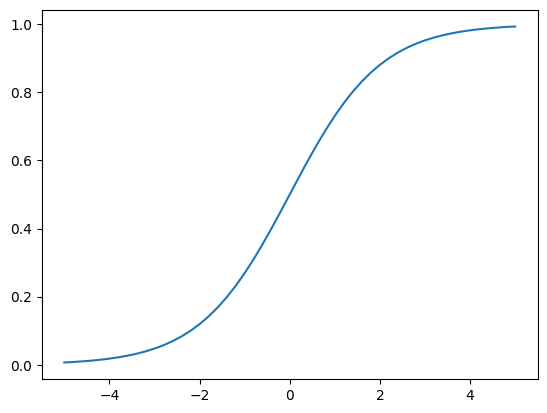

In [215]:
plt.plot(z, sigmoid(z))

In [216]:
def logistic_reg(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result
    


## 3.10 Training Logistic Regression with Scikit-Learn 

In [217]:
from sklearn.linear_model import LogisticRegression

In [218]:
model = LogisticRegression()

In [219]:
model.fit(X_train, y_train)

LogisticRegression()

In [222]:
model.coef_[0].round(3)

array([ 0.475, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.335,  0.317, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.124, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [224]:
model.intercept_[0]

-0.10903376915031196

In [225]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1])

In [226]:
y_pred = model.predict_proba(X_val)[:, 1]

In [228]:
y_pred

array([0.00899723, 0.20452842, 0.21222586, ..., 0.1363944 , 0.79977064,
       0.83740732])

In [229]:
churn_decision = (y_pred >= 0.5)

In [231]:
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 311, dtype: object

In [235]:
y_val

array([0, 0, 0, ..., 0, 1, 1])

In [282]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 0, 1])

In [237]:
# Accuracy
(y_val == churn_decision).mean()

0.8034066713981547

## 3.11 Model Interpretation


In [239]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [238]:
model.coef_

array([[ 4.74750135e-01, -1.74870499e-01, -4.07558284e-01,
        -2.96939403e-02, -7.79847072e-02,  6.26811145e-02,
        -8.89720520e-02, -8.13877099e-02, -3.43097486e-02,
        -7.33688988e-02, -3.35210368e-01,  3.16503772e-01,
        -8.89720520e-02,  3.67496833e-03, -2.58133897e-01,
         1.41448393e-01,  9.00685705e-03,  6.25288506e-02,
        -8.89720520e-02, -8.12354460e-02,  2.65580841e-01,
        -8.89720520e-02, -2.84287436e-01, -2.31194264e-01,
         1.23515616e-01, -1.66028435e-01,  5.83497871e-02,
        -8.70083362e-02, -3.20549323e-02,  7.04724498e-02,
        -5.90878289e-02,  1.41448393e-01, -2.49127040e-01,
         2.15473658e-01, -1.20367304e-01, -8.89720520e-02,
         1.01660709e-01, -7.08954412e-02, -8.89720520e-02,
         5.21888458e-02,  2.13371188e-01, -8.89720520e-02,
        -2.32077784e-01, -7.04046126e-02,  3.82358259e-04]])

In [242]:
dict(zip(dv.get_feature_names_out(), model.coef_[0]))

{'contract=month-to-month': 0.47475013499282726,
 'contract=one_year': -0.17487049858586431,
 'contract=two_year': -0.4075582838879628,
 'dependents=no': -0.029693940327888257,
 'dependents=yes': -0.07798470715776855,
 'deviceprotection=no': 0.06268111445172671,
 'deviceprotection=no_internet_service': -0.088972052037029,
 'deviceprotection=yes': -0.08138770989865866,
 'gender=female': -0.03430974863983297,
 'gender=male': -0.07336889884497785,
 'internetservice=dsl': -0.3352103676344584,
 'internetservice=fiber_optic': 0.31650377218558445,
 'internetservice=no': -0.088972052037029,
 'monthlycharges': 0.0036749683270690184,
 'multiplelines=no': -0.2581338970658477,
 'multiplelines=no_phone_service': 0.1414483925308323,
 'multiplelines=yes': 0.00900685705181368,
 'onlinebackup=no': 0.06252885055107549,
 'onlinebackup=no_internet_service': -0.088972052037029,
 'onlinebackup=yes': -0.08123544599876835,
 'onlinesecurity=no': 0.26558084091310846,
 'onlinesecurity=no_internet_service': -0.08

In [243]:
small = ['contract', 'tenure', 'monthlycharges']


In [244]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
5,month-to-month,4,30.50
6,month-to-month,1,75.10
7,month-to-month,1,70.30
8,two_year,72,19.75
9,month-to-month,6,109.90


In [245]:
dicts_train_small = df_train[small].to_dict(orient='records')

In [246]:
dicts_val_small = df_train[small].to_dict(orient='records')

In [248]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [249]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [250]:
X_train_small = dv_small.transform(dicts_train_small)

In [252]:
model_small = LogisticRegression()

In [253]:
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [261]:
# w0
w0 =model_small.intercept_[0]
w0


-2.4767756595983106

In [262]:
w = model_small.coef_[0]
w

array([ 0.97004491, -0.02513651, -0.94872202,  0.02748236, -0.03618424])

In [260]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': 0.97,
 'contract=one_year': -0.025,
 'contract=two_year': -0.949,
 'monthlycharges': 0.027,
 'tenure': -0.036}

## 3.12 Using the model


In [263]:
dicts_full_train = df_full_train[categorical+numerical].to_dict(orient='records')

In [264]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [265]:
y_full_train = df_full_train.churn.values

In [266]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

LogisticRegression()

In [273]:
dicts_test = df_test[categorical+numerical].to_dict(orient='records')

In [274]:
X_test = dv.transform(dicts_test)
y_pred = model.predict_proba(X_test)[:,1]

In [275]:
churn_decision = (y_pred >= 0.5)

In [276]:
(churn_decision == y_test).mean()

0.815471965933286

In [277]:
# USAGE

In [278]:
customer = dicts_test[10]

In [279]:
X_small = dv.transform([customer])

In [280]:

model.predict_proba(X_small)[0, 1]

0.4056810977920908

In [281]:
y_test[10]

0